In [1]:
# importing the file

In [31]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.io import fits
import matplotlib.pyplot as plt

In [32]:
image = '../images/hlsp_ceers_jwst_nircam_nircam5_f444w_dr0.6_i2d.fits'
file = fits.open(image)

In [33]:
# checking the image structure

In [34]:
file.info()

Filename: ../images/hlsp_ceers_jwst_nircam_nircam5_f444w_dr0.6_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     375   ()      
  1  SCI_BKSUB     1 ImageHDU        75   (11500, 6500)   float64   
  2  SCI           1 ImageHDU        75   (11500, 6500)   float32   
  3  ERR           1 ImageHDU        10   (11500, 6500)   float32   
  4  CON           1 ImageHDU        10   (11500, 6500, 1)   int32   
  5  WHT           1 ImageHDU         9   (11500, 6500)   float32   
  6  VAR_POISSON    1 ImageHDU         9   (11500, 6500)   float32   
  7  VAR_RNOISE    1 ImageHDU         9   (11500, 6500)   float32   
  8  VAR_FLAT      1 ImageHDU         9   (11500, 6500)   float32   
  9  BKGD          1 ImageHDU        39   (11500, 6500)   float64   
 10  BKGMASK       1 ImageHDU        41   (11500, 6500)   uint8 (rescales to int8)   
 11  HDRTAB        1 BinTableHDU    820   6R x 405C   [23A, 5A, 3A, 51A, 7A, 13A, 3A, 5A, 7A, 10A, 4A, L, 

In [35]:
sci = file["SCI"].data
err = file["ERR"].data
sci_bkgsub = file["SCI_BKSUB"].data

In [36]:
# subtracting the background by median method to exclue sky pixels from the glow of background. 

In [37]:
test = file["SCI"].data

In [38]:
wht = file["WHT"].data
nodata = (wht <= 0) | (test == 0) | ~np.isfinite(test)
print(nodata.mean())

0.5013612173913043


In [39]:
test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6500, 11500), dtype='>f4')

In [40]:
h, w = test.shape
tile = 200
n_rows, n_cols = h // tile, w // tile
medians = np.full((n_rows, n_cols), np.nan)
spreads = np.full((n_rows, n_cols), np.nan)

for i in range(n_rows):
    for j in range(n_cols):
        box      = test[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
        box_mask = nodata[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
        real = box[~box_mask]
        if real.size < 0.5 * box.size:
            continue                            # leave this box as NaN
        mean, med, stddev = sigma_clipped_stats(real)
        medians[i, j] = med                     # sky level of this box
        spreads[i, j] = stddev 

In [41]:
sky   = np.nanmedian(medians)      # one global sky level
noise = np.nanmedian(spreads)      # one global noise level
rms   = np.sqrt(np.nanmedian(spreads**2))
n = 5                              # our chosen nsigma

threshold = sky + n * noise        # "center plus n spreads" — the line we draw
suspects = (test > threshold) & ~nodata   # True where a pixel pokes above the line
print(suspects.mean())             # fraction of pixels flagged

0.012324334448160536


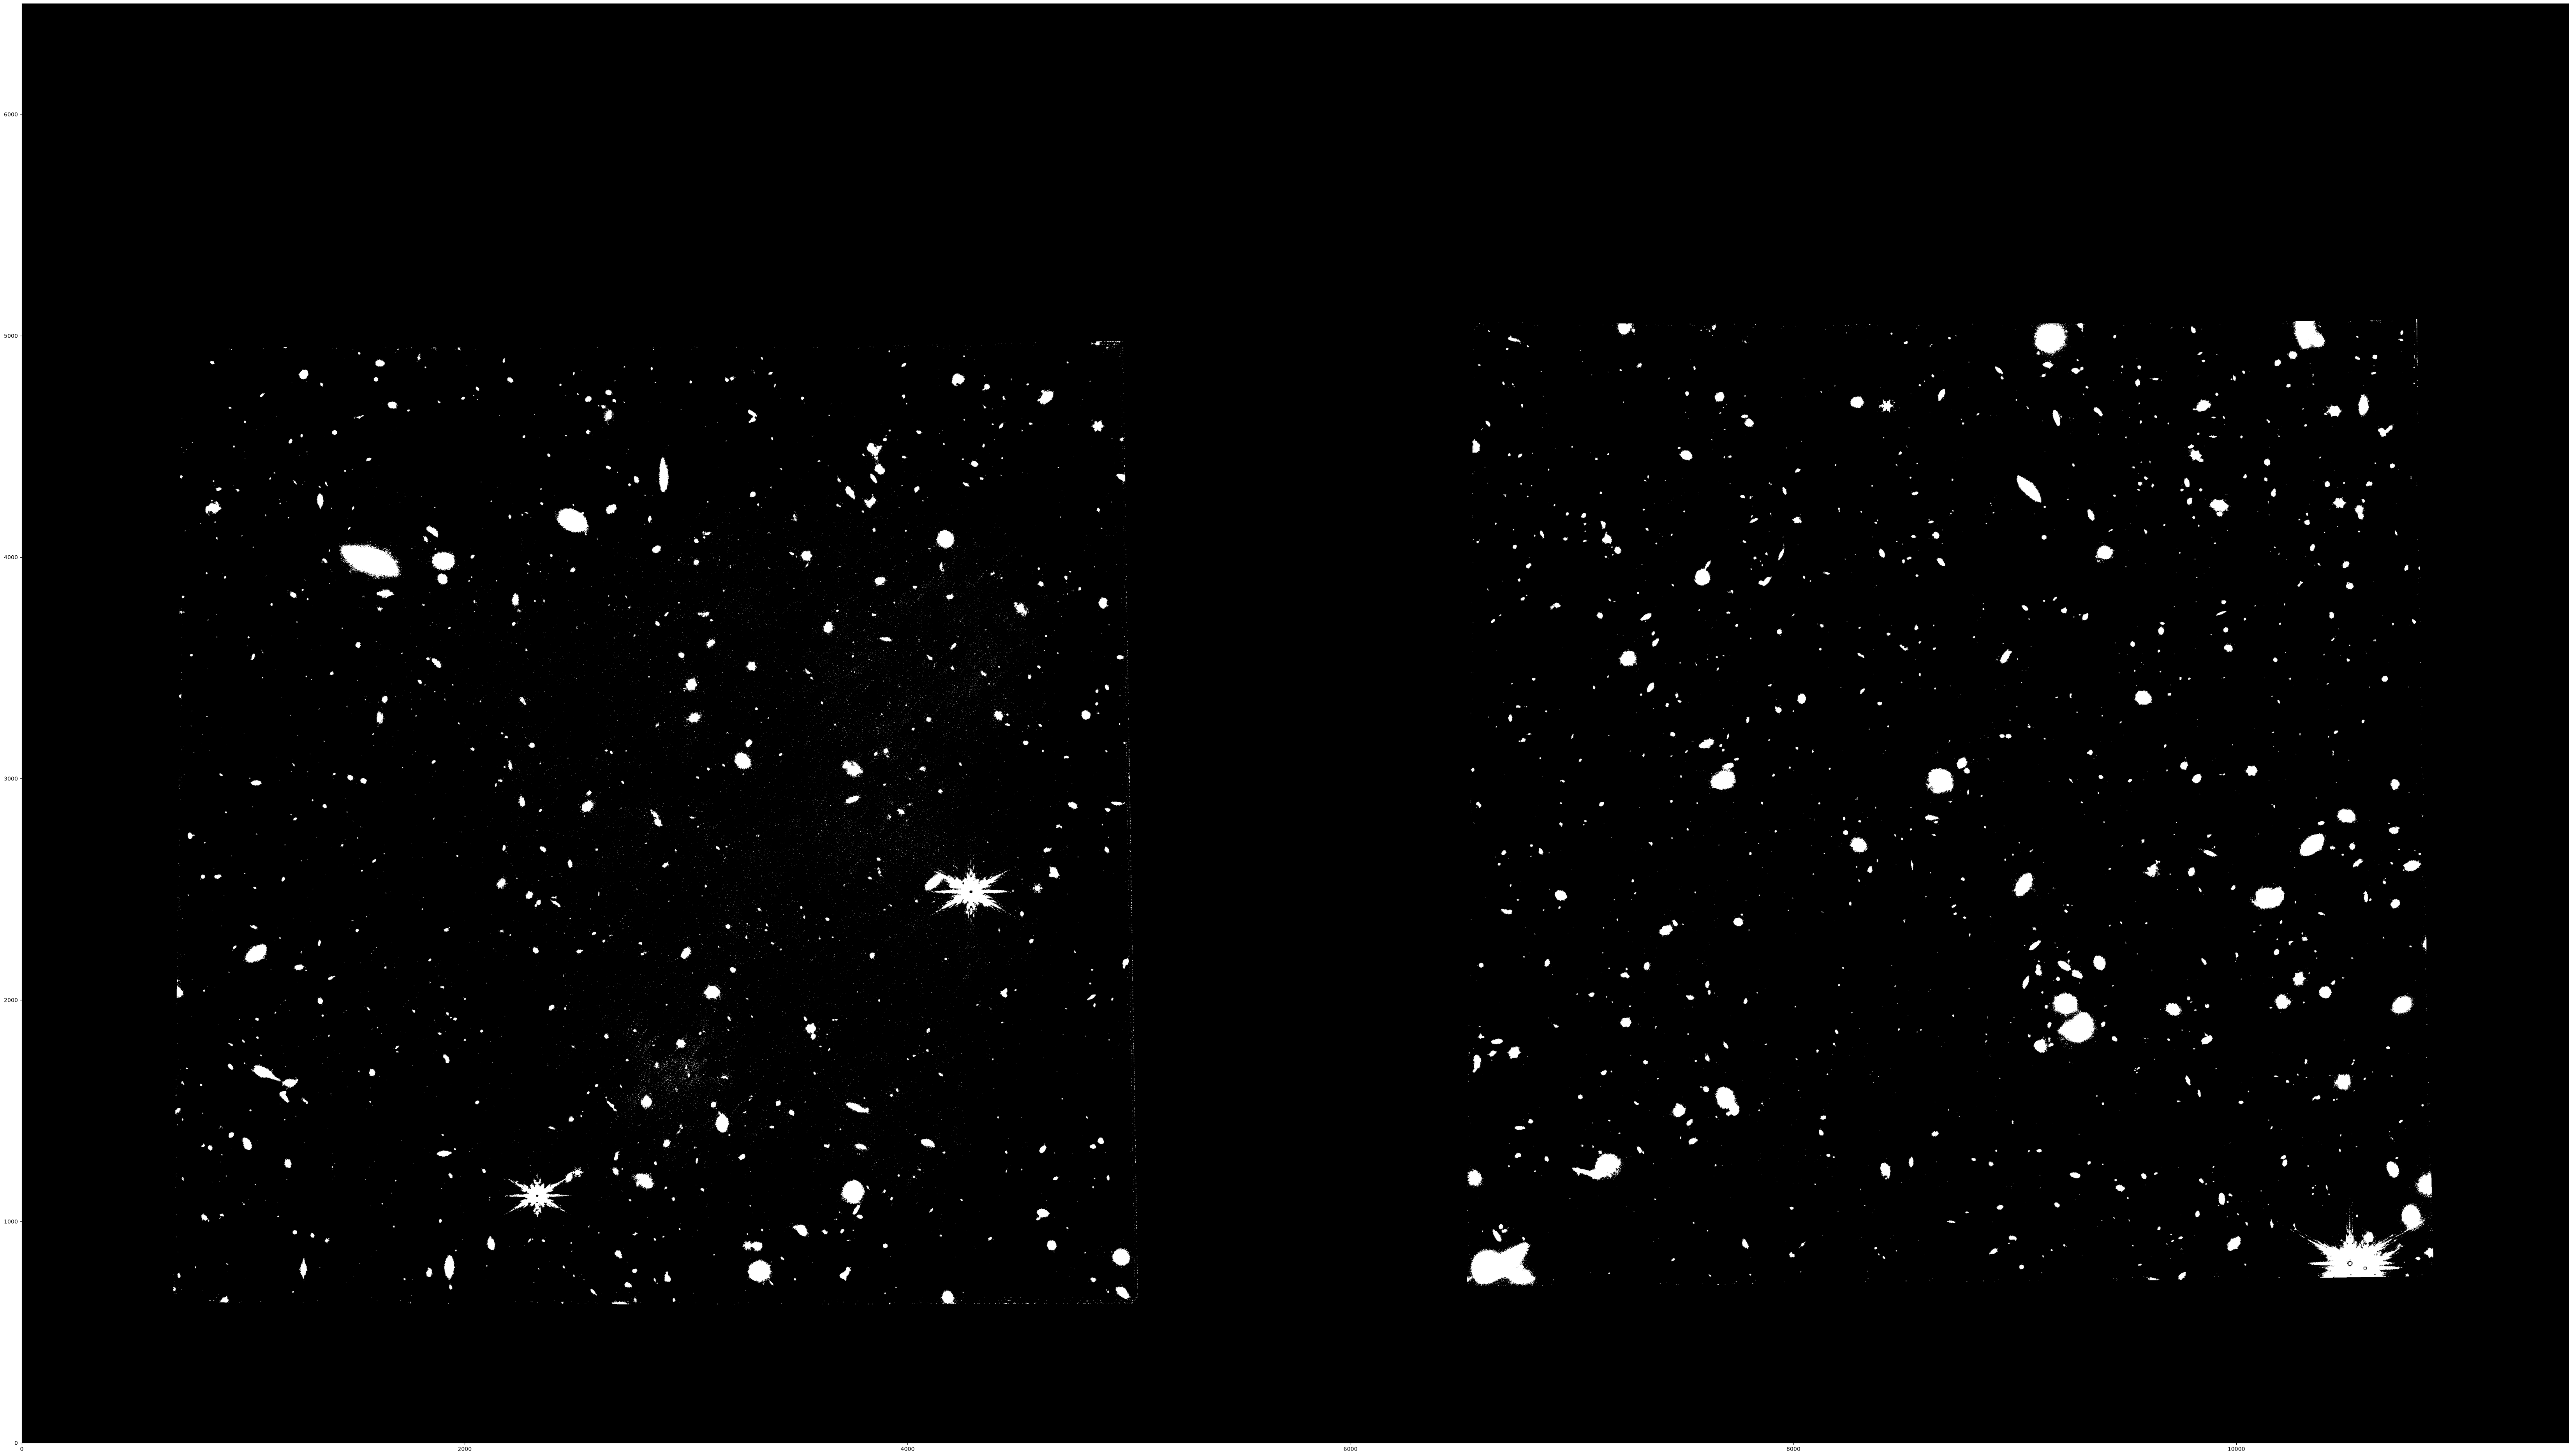

In [42]:
plt.figure(figsize=(96, 48))
plt.imshow(suspects, origin="lower", cmap="grey")
plt.show()

In [43]:
# detection & labeling

In [44]:
# del refined, sci_bkgsub  # deleting these arrays from the memory
y0, y1, x0, x1 = 3000, 5000, 1000, 3000
cut      = test[y0:y1, x0:x1].astype(np.float64)
cut_mask = nodata[y0:y1, x0:x1]
print(cut_mask.mean())   # want this small — if near 1, pick a different region

0.02594725


In [45]:
from photutils.segmentation import detect_sources

cut_sub = cut - sky
segm = detect_sources(cut_sub, threshold=n * noise, npixels=5, mask=cut_mask)
print(segm.nlabels)

349


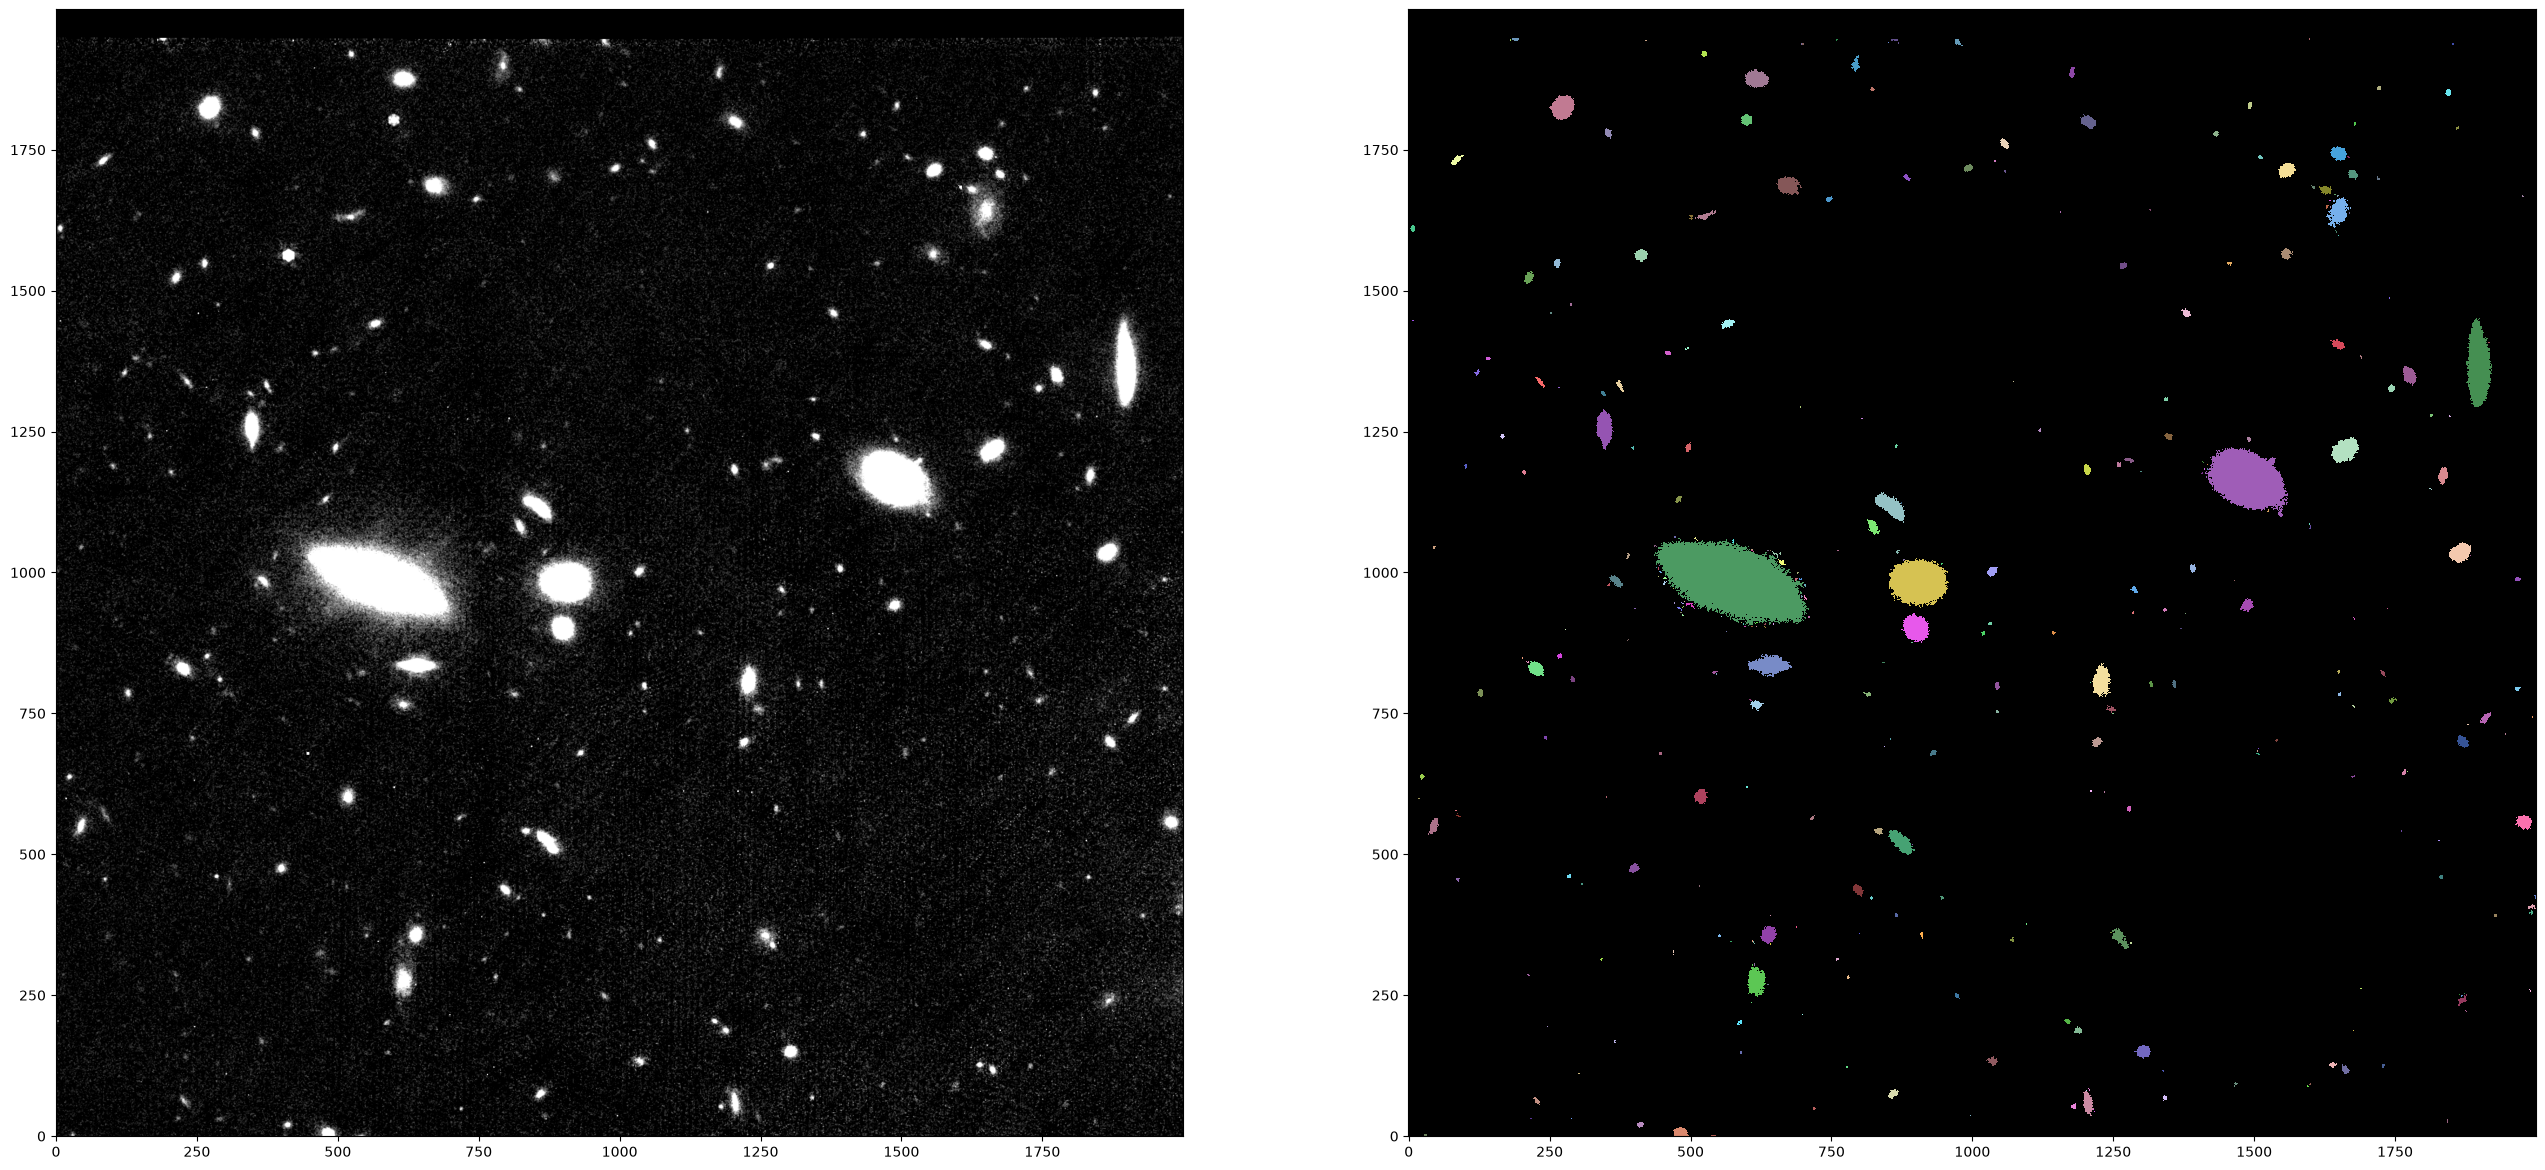

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(cut_sub, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm.data, origin="lower", cmap=segm.cmap, interpolation="nearest")
plt.show()

In [47]:
from scipy.ndimage import zoom

spreads_cut = spreads[15:25, 5:15]
spreads_cut = np.where(np.isnan(spreads_cut), rms, spreads_cut)
rms_cut = zoom(spreads_cut, 200, order=1)
print(rms_cut.shape)

(2000, 2000)


In [48]:
segm_local = detect_sources(cut_sub, threshold=n * rms_cut, n_pixels=5, mask=cut_mask)
print(segm_local.n_labels)

237


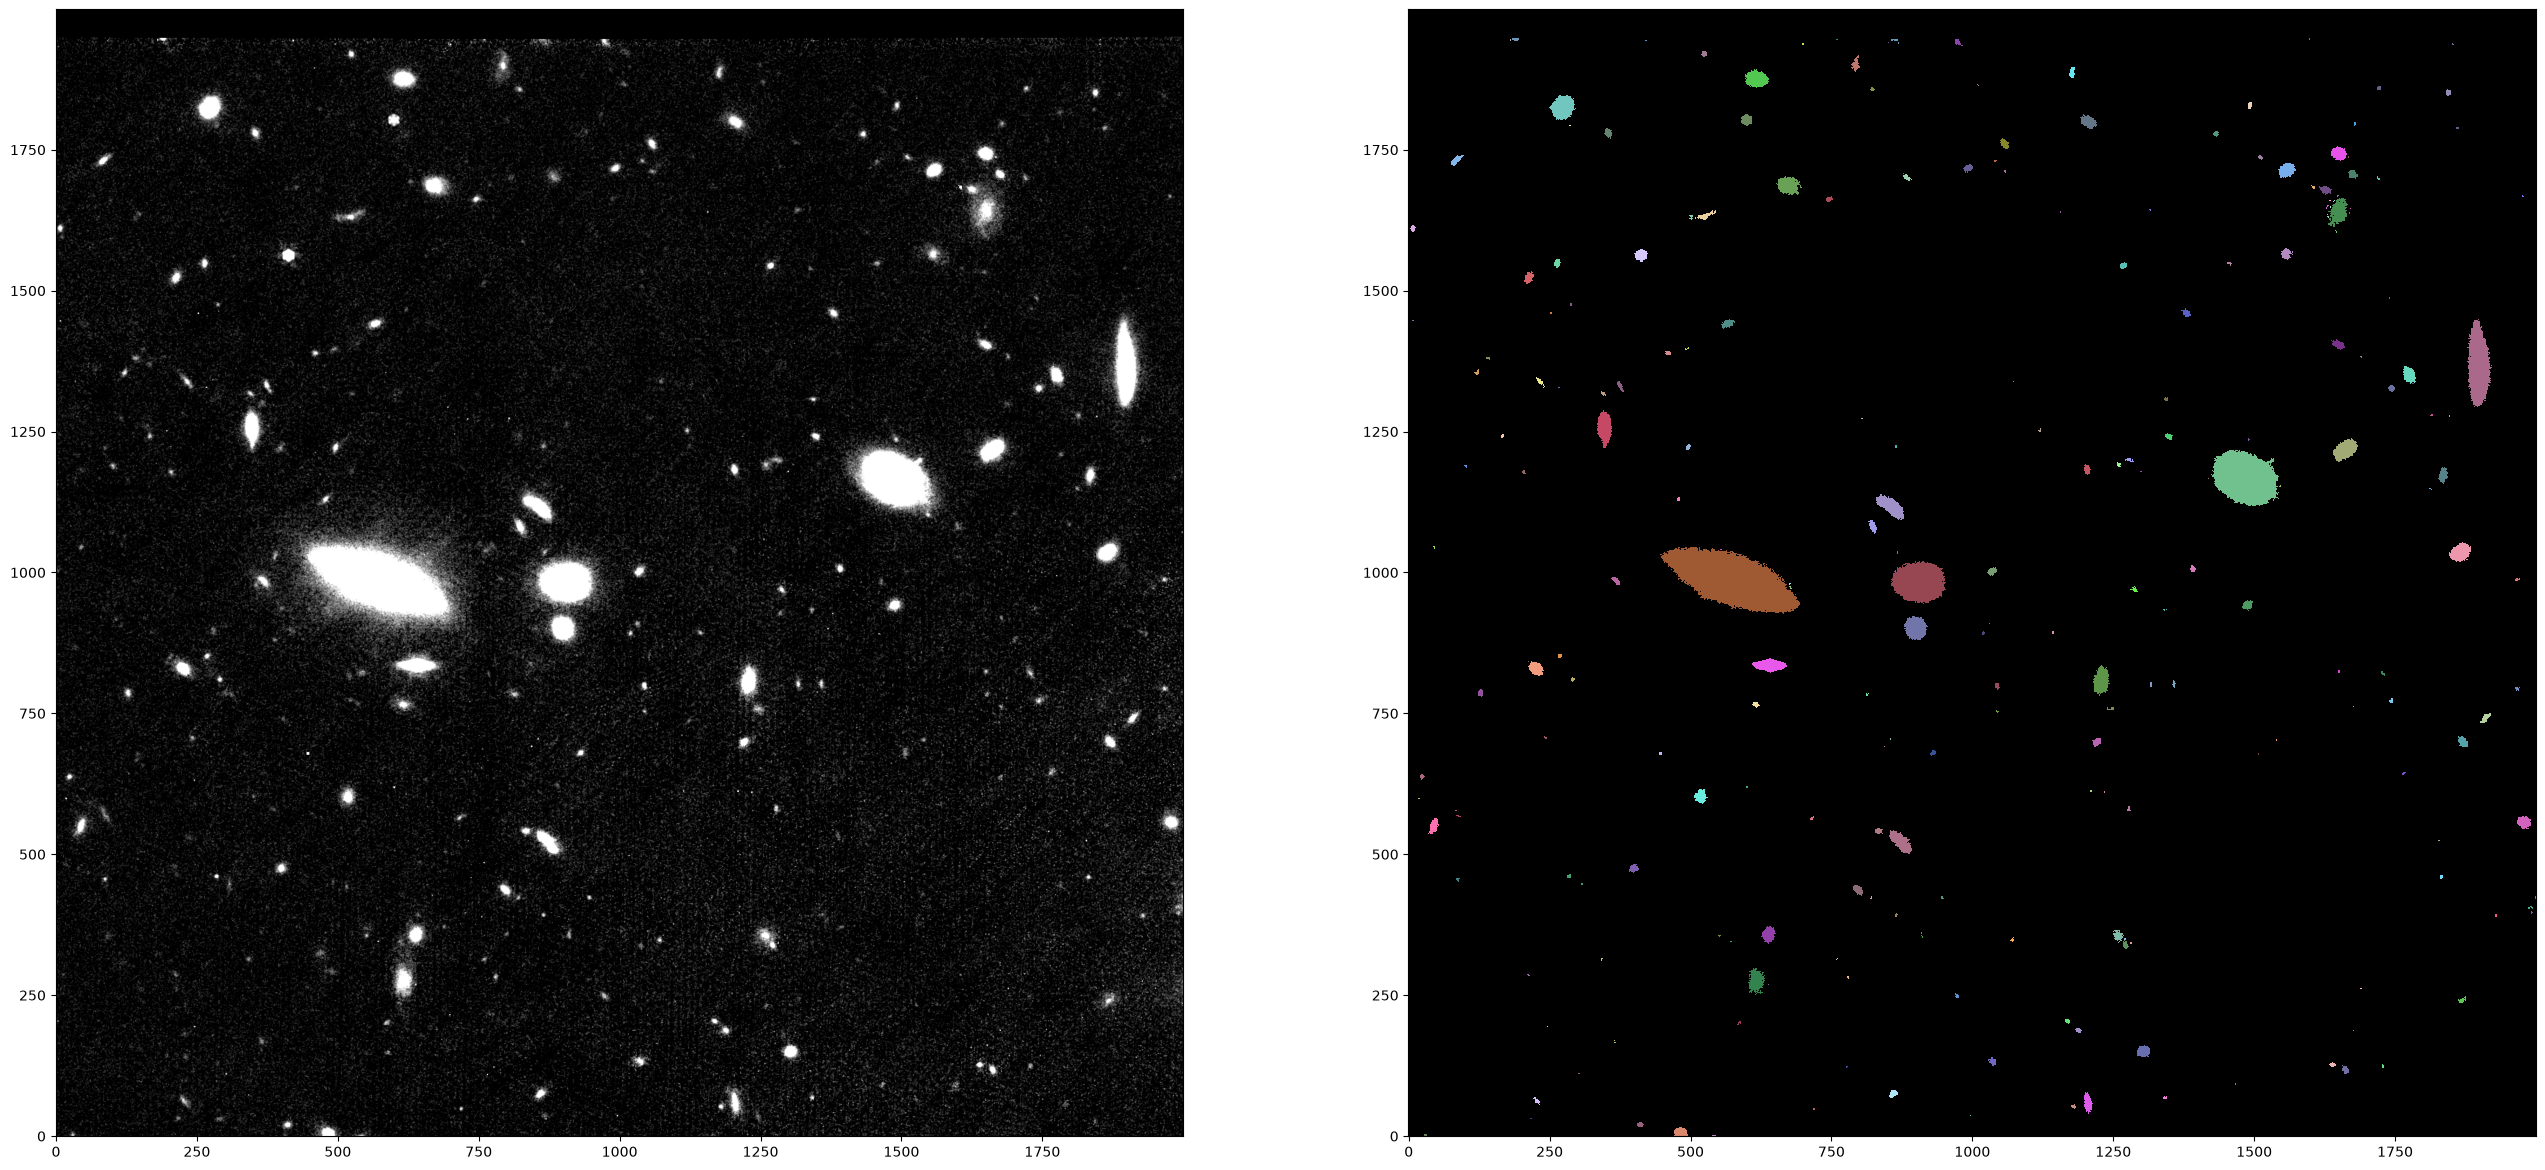

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(cut_sub, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm_local.data, origin="lower", cmap=segm.cmap, interpolation="nearest")
plt.show()

In [50]:
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel

kernel = make_2dgaussian_kernel(5.0, size=11)
conv = convolve(cut_sub, kernel)

segm_conv = detect_sources(conv, threshold=n * rms_cut, n_pixels=5, mask=cut_mask)
print(segm_conv.n_labels)

129


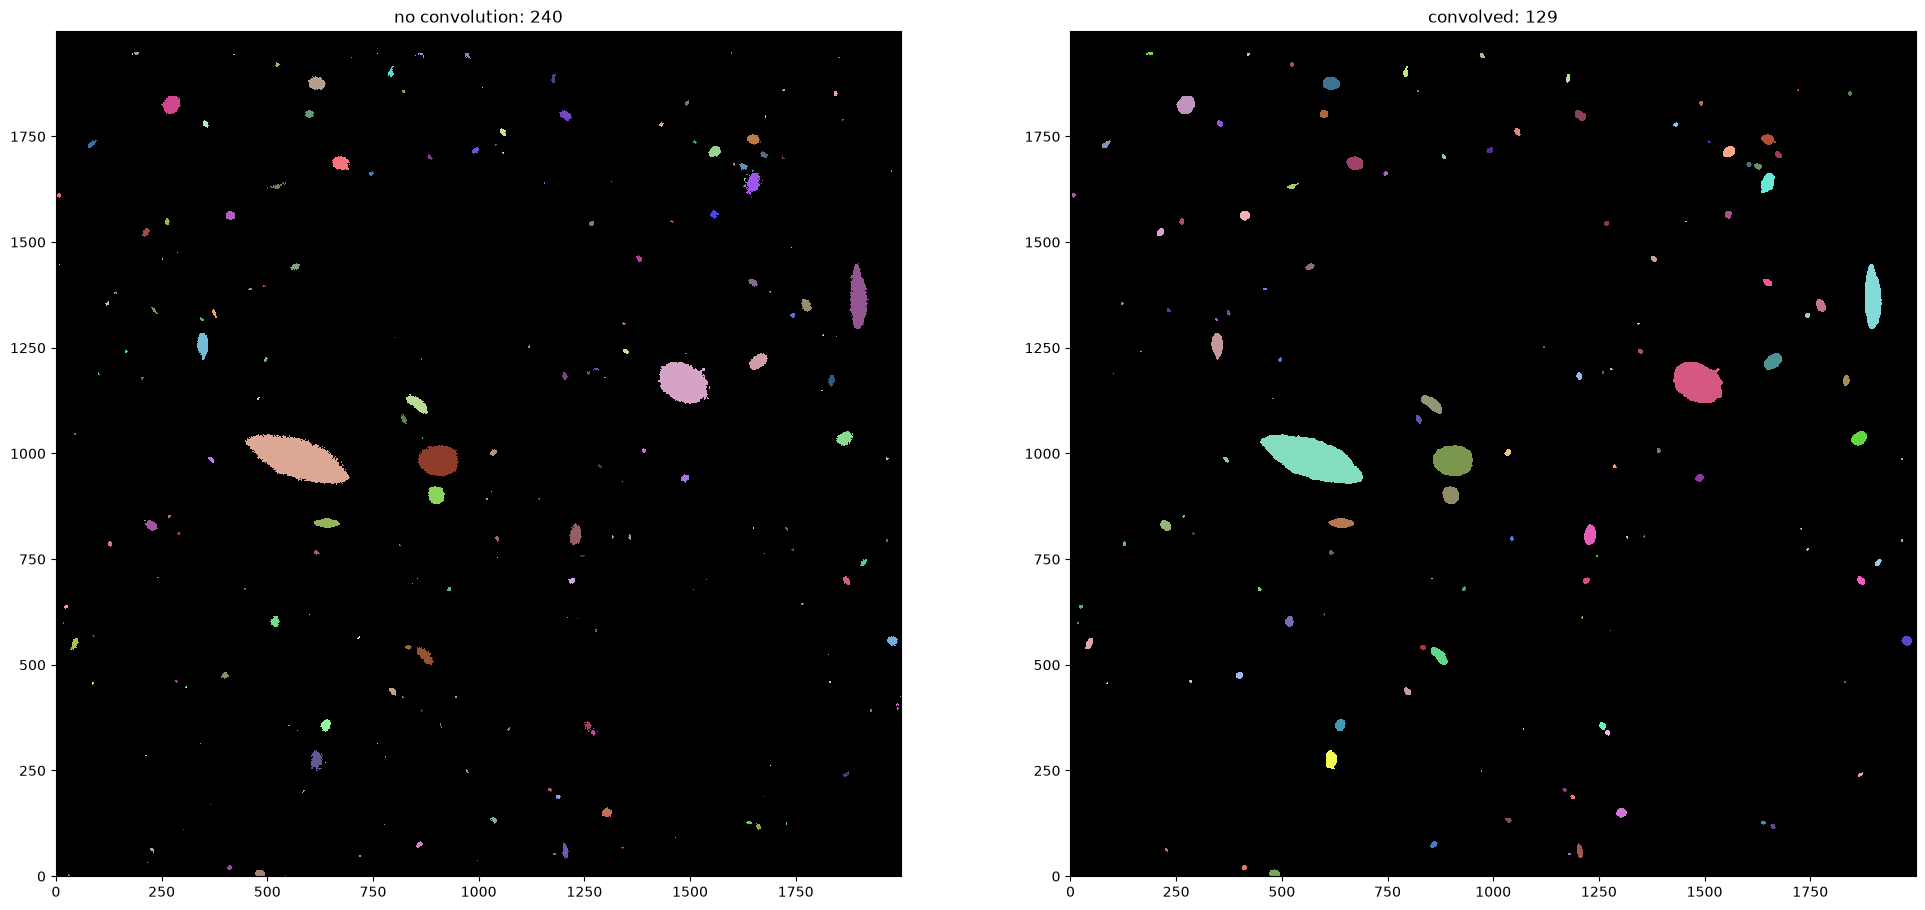

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(segm_local.data, origin="lower", cmap=segm_local.cmap, interpolation="nearest")
ax[0].set_title("no convolution: 240")
ax[1].imshow(segm_conv.data, origin="lower", cmap=segm_conv.cmap, interpolation="nearest")
ax[1].set_title("convolved: 129")
plt.show()

In [52]:
print(segm_local.areas.sum(), segm_conv.areas.sum())

67707 67632


In [53]:
from photutils.segmentation import deblend_sources

segm_deblend = deblend_sources(
    conv,                # the convolved image
    segm_conv,           # the segmentation to split up
    npixels=5,           # or n_pixels=5 if your version wants that
    nlevels=32,
    contrast=0.01,
    progress_bar=False,
)
print(segm_deblend.n_labels)

137


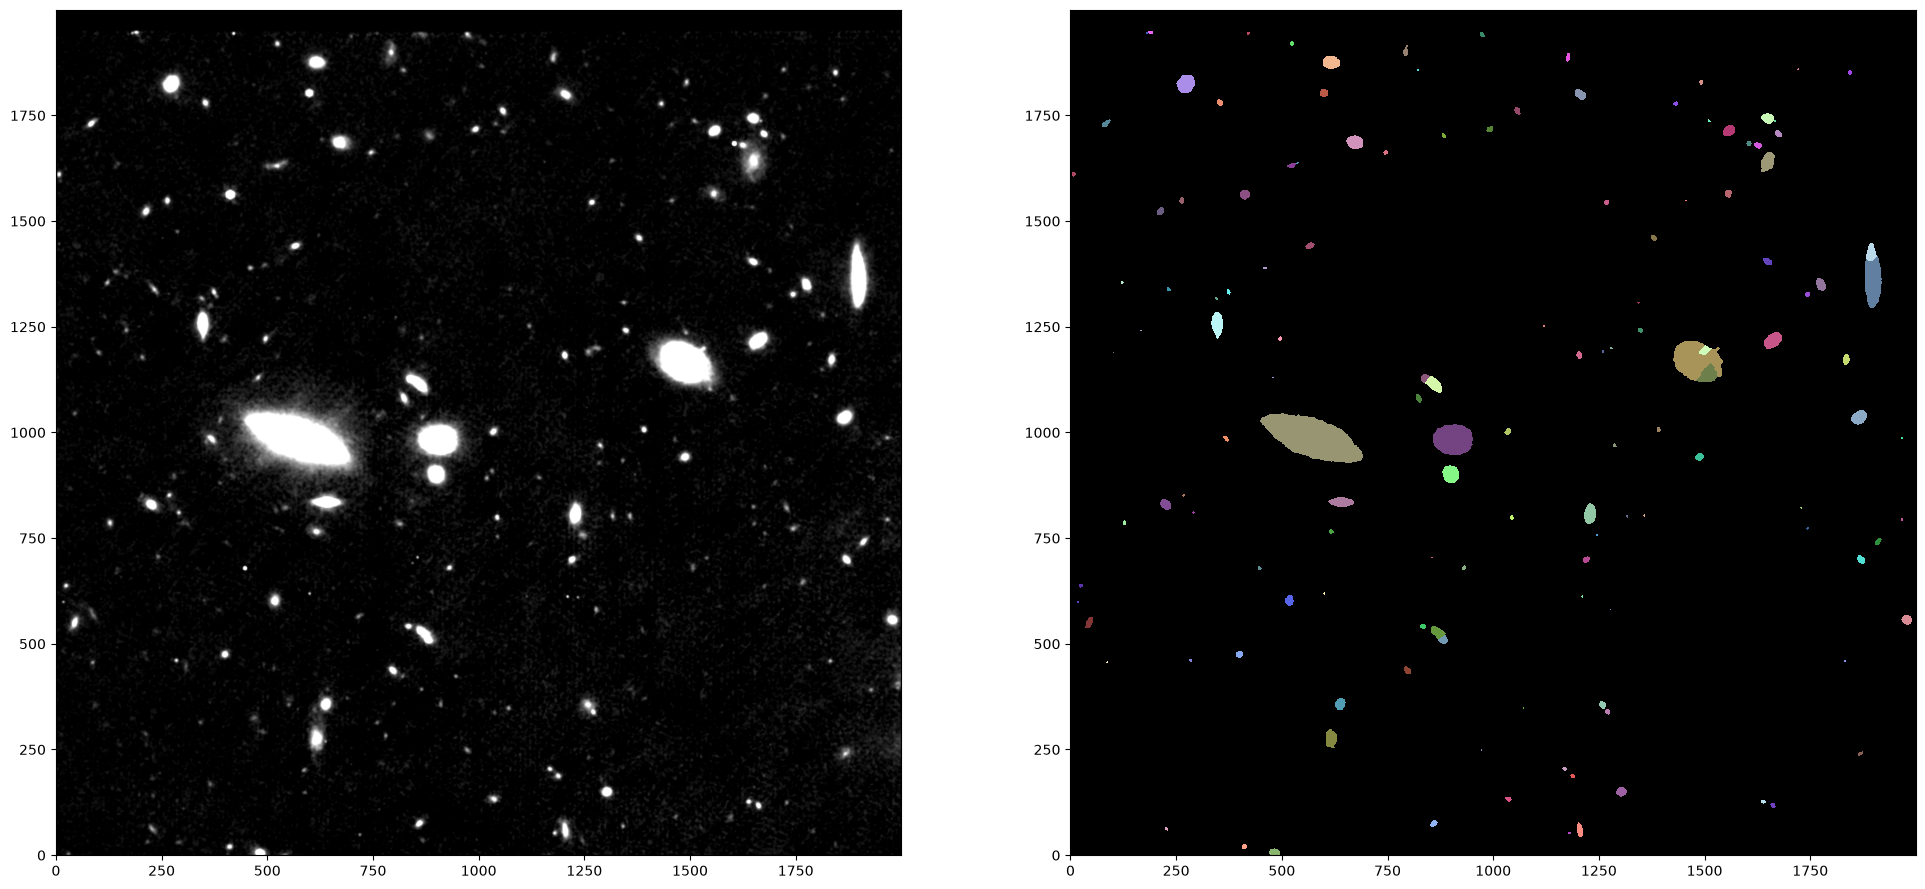

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(conv, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm_deblend.data, origin="lower", cmap=segm_deblend.cmap,
             interpolation="nearest")
plt.show()

In [66]:
ksize = int(2 * np.ceil(2 * psf_fwhm_pix) + 1)      # odd, ~4x FWHM wide
kernel = make_2dgaussian_kernel(psf_fwhm_pix, size=ksize)
conv = convolve(cut_sub, kernel)

MIN_NPIX = int(np.ceil(0.5 * psf_area_pix))         # ~half a PSF footprint

segm_conv = detect_sources(conv, threshold=n * rms_cut,
                           n_pixels=MIN_NPIX, mask=cut_mask)
segm_deblend = deblend_sources(conv, segm_conv, n_pixels=MIN_NPIX,
                               n_levels=32, contrast=0.001, progress_bar=False)
print(f"kernel {psf_fwhm_pix:.2f} px, n_pixels {MIN_NPIX} -> "
      f"{segm_conv.n_labels} detected, {segm_deblend.n_labels} after deblend")

kernel 4.83 px, n_pixels 10 -> 126 detected, 131 after deblend


In [56]:
# Implementing the catalog

In [57]:
from astropy.wcs import WCS
wcs_full = WCS(file["SCI"].header)
wcs_cut  = wcs_full[y0:y1, x0:x1]

Set DATE-AVG to '2022-12-21T13:09:40.140' from MJD-AVG.
Set DATE-END to '2022-12-21T13:36:37.819' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [58]:
err_cut = err[y0:y1, x0:x1].astype(np.float64)

In [67]:
cat = SourceCatalog(
    data=cut_sub,
    segmentation_image=segm_deblend,     # was segment_img
    convolved_data=conv,
    error=err_cut,
    mask=cut_mask,
    wcs=wcs_cut,
)

tbl = cat.to_table(columns=[
    "label", "x_centroid", "y_centroid", "sky_centroid",
    "bbox_xmin", "bbox_xmax", "bbox_ymin", "bbox_ymax",
    "area", "segment_flux", "segment_flux_err",
    "semimajor_axis", "semiminor_axis", "eccentricity", "orientation",
    "max_value",
])
print(len(tbl), "sources")

131 sources


In [68]:
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

pixscale = (proj_plane_pixel_scales(wcs_cut)[0] * u.deg).to(u.arcsec).value
psf_fwhm_arcsec = 0.145                      # F444W — verify against JWST docs
psf_fwhm_pix    = psf_fwhm_arcsec / pixscale
psf_sigma_pix   = psf_fwhm_pix / 2.355
psf_area_pix    = np.pi * (psf_fwhm_pix / 2)**2

print(f"{pixscale:.4f} arcsec/pix | FWHM {psf_fwhm_pix:.2f} pix | "
      f"sigma {psf_sigma_pix:.2f} pix | PSF area {psf_area_pix:.1f} pix2")

0.0300 arcsec/pix | FWHM 4.83 pix | sigma 2.05 pix | PSF area 18.3 pix2


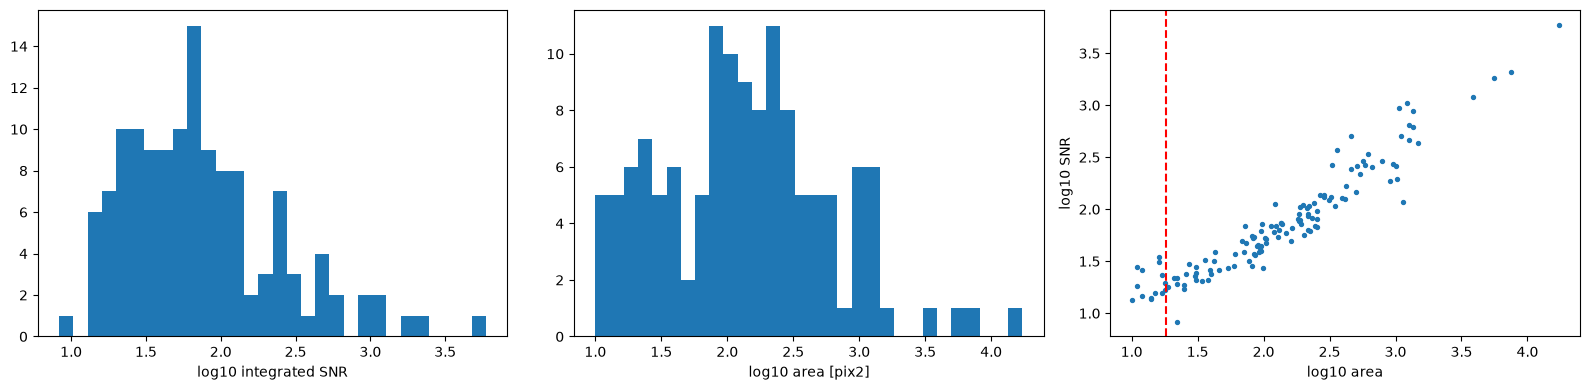

In [69]:
snr = (tbl["segment_flux"] / tbl["segment_flux_err"]).value

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(np.log10(snr), bins=30);                      ax[0].set_xlabel("log10 integrated SNR")
ax[1].hist(np.log10(tbl["area"].value), bins=30);        ax[1].set_xlabel("log10 area [pix2]")
ax[2].scatter(np.log10(tbl["area"].value), np.log10(snr), s=8)
ax[2].set_xlabel("log10 area"); ax[2].set_ylabel("log10 SNR")
ax[2].axvline(np.log10(np.pi * psf_fwhm_pix**2 / 4), color="r", ls="--")
plt.tight_layout(); plt.show()

zero flux: 0 | negative: 0 | bad err: 0
131 of 131 plottable
snr        [ 16.29  28.95  63.05 129.98 764.46]
area       [  14.5   42.5  128.   325.5 1309.5]
semiminor  [0.91 1.53 2.51 3.49 6.76]


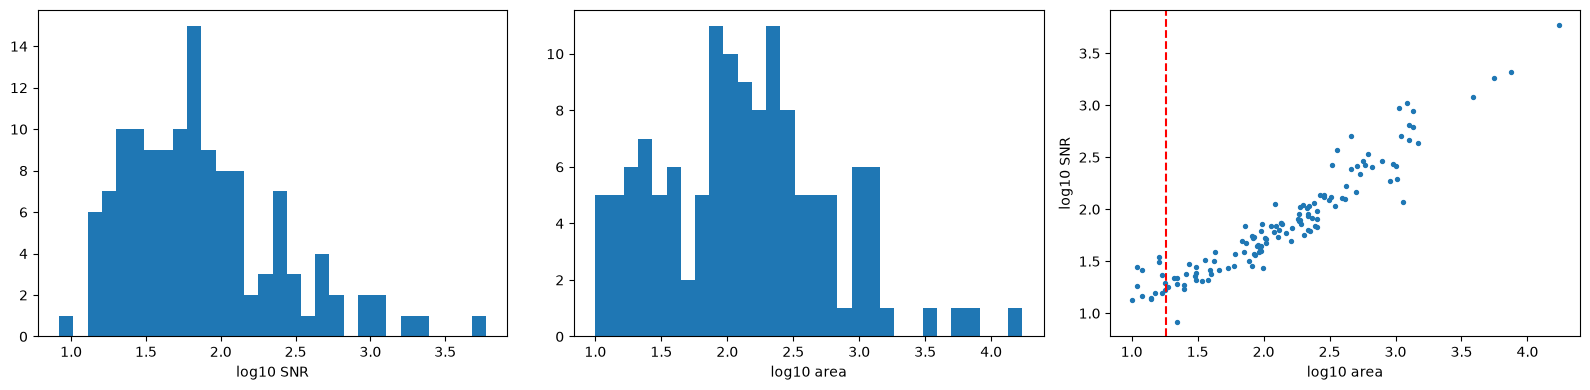

In [70]:
flux = tbl["segment_flux"].value
ferr = tbl["segment_flux_err"].value

snr = np.divide(flux, ferr, out=np.full_like(flux, np.nan), where=(ferr > 0))
tbl["snr"] = snr

print("zero flux:", (flux == 0).sum(), "| negative:", (flux < 0).sum(),
      "| bad err:", ((ferr <= 0) | ~np.isfinite(ferr)).sum())

ok = np.isfinite(snr) & (snr > 0) & (tbl["area"].value > 0)
print(f"{ok.sum()} of {len(tbl)} plottable")

for name, arr in [("snr", snr[ok]),
                  ("area", tbl["area"].value[ok]),
                  ("semiminor", tbl["semiminor_axis"].value[ok])]:
    print(f"{name:10s}", np.percentile(arr, [5, 25, 50, 75, 95]).round(2))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(np.log10(snr[ok]), bins=30); ax[0].set_xlabel("log10 SNR")
ax[1].hist(np.log10(tbl["area"].value[ok]), bins=30); ax[1].set_xlabel("log10 area")
ax[2].scatter(np.log10(tbl["area"].value[ok]), np.log10(snr[ok]), s=8)
ax[2].axvline(np.log10(psf_area_pix), color="r", ls="--")
ax[2].set_xlabel("log10 area"); ax[2].set_ylabel("log10 SNR")
plt.tight_layout(); plt.show()

In [71]:
MIN_SEMIMINOR = 0.8 * psf_sigma_pix
MIN_AREA      = psf_area_pix
MIN_SNR       = 10.0
EDGE_BUFFER   = 10
MAX_BADFRAC   = 0.05

ny, nx = cut_sub.shape
tbl["badfrac"] = np.array([cut_mask[sl].mean() for sl in segm_deblend.slices])

tbl["flag_badflux"]    = ~np.isfinite(snr) | (flux <= 0)
tbl["flag_unresolved"] = tbl["semiminor_axis"].value < MIN_SEMIMINOR
tbl["flag_small"]      = tbl["area"].value < MIN_AREA
tbl["flag_lowsnr"]     = np.nan_to_num(snr, nan=-1) < MIN_SNR
tbl["flag_edge"] = ((tbl["bbox_xmin"] < EDGE_BUFFER) |
                    (tbl["bbox_ymin"] < EDGE_BUFFER) |
                    (tbl["bbox_xmax"] > nx - EDGE_BUFFER) |
                    (tbl["bbox_ymax"] > ny - EDGE_BUFFER))
tbl["flag_baddata"] = tbl["badfrac"] > MAX_BADFRAC

flagcols = ["flag_badflux", "flag_unresolved", "flag_small",
            "flag_lowsnr", "flag_edge", "flag_baddata"]
tbl["keep"] = ~np.any([np.asarray(tbl[c]) for c in flagcols], axis=0)

for c in flagcols:
    print(f"{c:18s} {np.asarray(tbl[c]).sum():4d}")
print(f"{'KEEP':18s} {np.asarray(tbl['keep']).sum():4d} of {len(tbl)}")

flag_badflux          0
flag_unresolved      35
flag_small           14
flag_lowsnr           1
flag_edge             3
flag_baddata          0
KEEP                 93 of 131


In [72]:
from astropy.nddata import Cutout2D

PAD, MIN_SIZE = 2.0, 32

def make_cutouts(row, pad=PAD):
    pos  = (row["x_centroid"], row["y_centroid"])
    bw   = row["bbox_xmax"] - row["bbox_xmin"] + 1
    bh   = row["bbox_ymax"] - row["bbox_ymin"] + 1
    side = int(max(MIN_SIZE, np.ceil(pad * max(bw, bh))))
    kw   = dict(position=pos, size=(side, side), mode="partial")

    c_sci = Cutout2D(cut_sub, wcs=wcs_cut, fill_value=np.nan, **kw)
    c_err = Cutout2D(err_cut, fill_value=np.nan, **kw)
    c_seg = Cutout2D(segm_deblend.data, fill_value=0, **kw)

    own = c_seg.data == row["label"]
    return dict(label=int(row["label"]),
                sci=c_sci.data, err=c_err.data, seg=c_seg.data,
                mask_own=own, mask_other=(c_seg.data != 0) & ~own,
                wcs=c_sci.wcs, row=row)

tbl_keep = tbl[np.asarray(tbl["keep"])]
cutouts  = {int(r["label"]): make_cutouts(r) for r in tbl_keep}
print(len(cutouts), "cutouts built")

93 cutouts built


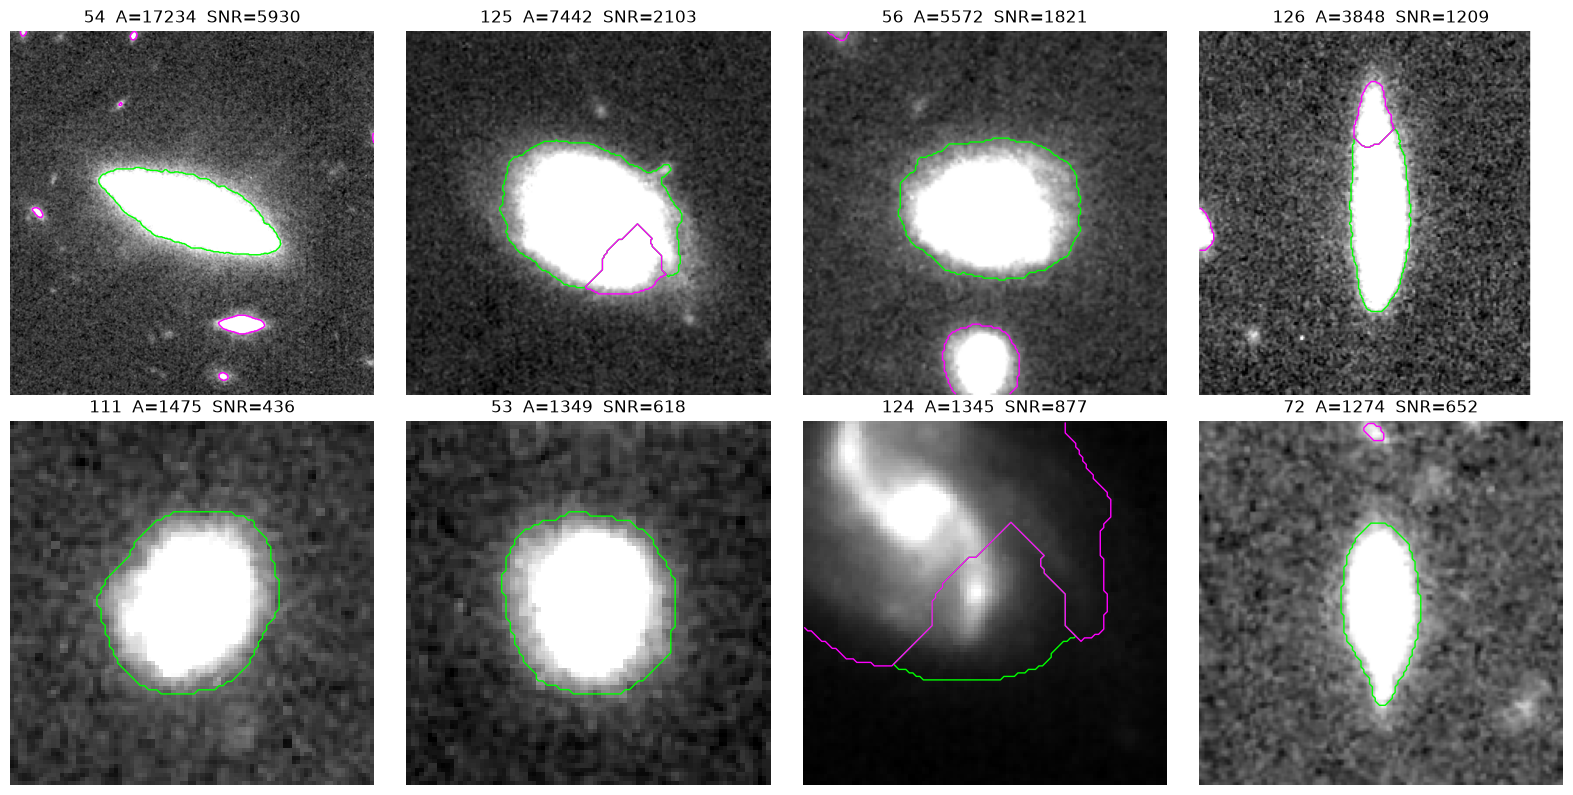

In [73]:
from astropy.visualization import ZScaleInterval
z = ZScaleInterval()

order = np.argsort(-tbl_keep["area"].value)          # largest first
picks = [int(tbl_keep["label"][i]) for i in order[:8]]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for a, lab in zip(axes.ravel(), picks):
    c = cutouts[lab]
    lo, hi = z.get_limits(np.nan_to_num(c["sci"]))
    a.imshow(c["sci"], origin="lower", cmap="grey", vmin=lo, vmax=hi)
    a.contour(c["mask_own"],   levels=[0.5], colors="lime",    linewidths=1)
    a.contour(c["mask_other"], levels=[0.5], colors="magenta", linewidths=1)
    a.set_title(f"{lab}  A={c['row']['area'].value:.0f}  SNR={c['row']['snr']:.0f}")
    a.axis("off")
plt.tight_layout(); plt.show()

In [74]:
import os
outdir = "cutouts"; os.makedirs(outdir, exist_ok=True)

def write_cutout(c):
    r = c["row"]
    hdr = c["wcs"].to_header()
    p = fits.PrimaryHDU()
    p.header.update(LABEL=c["label"], FILTER="F444W", SURVEY="CEERS",
                    RA=float(r["sky_centroid"].ra.deg),
                    DEC=float(r["sky_centroid"].dec.deg),
                    AREA=float(r["area"].value), SNR=float(r["snr"]),
                    SMAJ=float(r["semimajor_axis"].value),
                    SMIN=float(r["semiminor_axis"].value),
                    ECC=float(r["eccentricity"]),
                    ORIENT=float(r["orientation"].value),
                    PIXSCALE=pixscale, PSFFWHM=psf_fwhm_pix)
    hdus = [p,
            fits.ImageHDU(c["sci"].astype(np.float32), hdr, name="SCI"),
            fits.ImageHDU(c["err"].astype(np.float32), hdr, name="ERR"),
            fits.ImageHDU(c["seg"].astype(np.int32),   hdr, name="SEGMAP"),
            fits.ImageHDU(c["mask_other"].astype(np.uint8), hdr, name="MASK")]
    fits.HDUList(hdus).writeto(f"{outdir}/src_{c['label']:05d}.fits", overwrite=True)

for c in cutouts.values():
    write_cutout(c)

tbl.write("catalog_full.ecsv", overwrite=True)      # all 183, flags included
print(len(cutouts), "files written")

93 files written
